In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')

In [3]:
from pipeline import portfolio, run
import pandas as pd
import yaml

with open('config.yml', 'r') as file:
    config = yaml.safe_load(file)

START = config['backtest_start']
END = config['backtest_end']

START_EVAL = config['start_eval']
END_EVAL = config['end_eval']

tickers = pd.read_csv('results/universe_selection/final_assets.csv', skiprows = 1, header = None)[0].tolist()

results = portfolio.aggregate_results(tickers, start = START, end = END)
portfolio_df = portfolio.build_portfolio(tickers, results)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
run.analyze_portfolio(portfolio_df, 'out_of_sample', start = START_EVAL, end = END_EVAL)
run.calculate_spy(start = START_EVAL, end = END_EVAL)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

Average Exposure: 0.6320561887006162


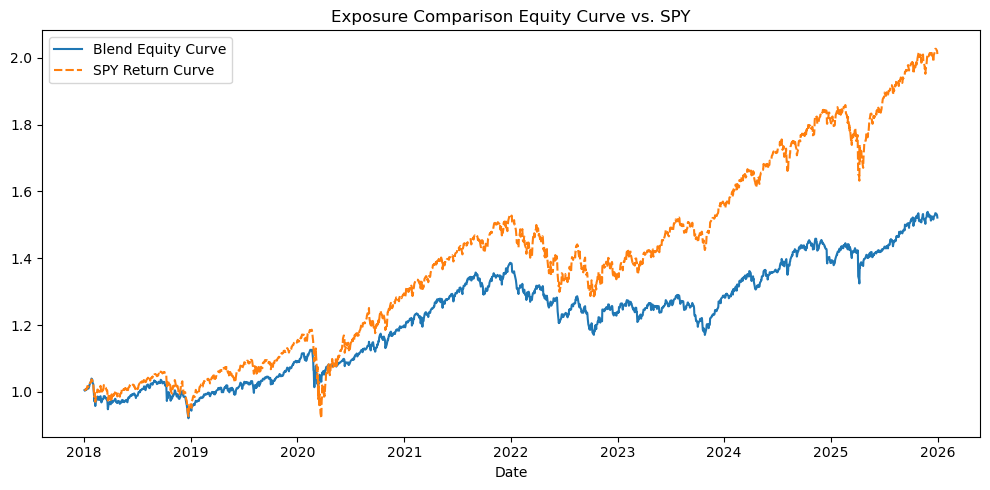

In [10]:
from evaluation import plot

avg_exposure = portfolio.average_exposure(tickers, results)
print(f'Average Exposure: {avg_exposure}')

_, spy_df = run.load_spy(start = '2018-01-01', end = '2026-01-01')
spy_benchmark = spy_df['Pct Return'] * 0.632
spy_benchmark_curve = (1 + spy_benchmark).cumprod()

portfolio_df = portfolio_df.loc['2018-01-01':'2026-01-01']
portfolio_df['Blend Equity Curve'] = (1 + portfolio_df['Blend Return']).cumprod()

exposure_comp = plot.plot_equity_curve(portfolio_df, 'Exposure Comparison', spy_benchmark_curve)

In [13]:
crash_results = {ticker: df.loc['2008-09-01': '2009-03-01'] for ticker, df in results.items()}
crash_exposure = portfolio.average_exposure(tickers, crash_results)
print(f'2008 Crash Exposure: {crash_exposure}')

2008 Crash Exposure: 0.3287999533110729


In [14]:
covid_results = {ticker: df.loc['2020-02-01': '2020-04-01'] for ticker, df in results.items()}
covid_exposure = portfolio.average_exposure(tickers, covid_results)
print(f'2020 COVID Exposure: {covid_exposure}')

2020 COVID Exposure: 0.5082095125018241
